# Data Analytics Project 3
## SQL Data Analysis

### Submitted by:
**Momina Malik**

### Internship:
DecodeLabs Data Analytics Internship

### Objective
The objective of this project is to analyze sales data using SQL queries. The project demonstrates SQL fundamentals including data selection, filtering, sorting, grouping, and aggregation to extract meaningful business insights from the dataset.

In [6]:
# Import libraries
import pandas as pd
import sqlite3

## Step 1: Load the Dataset

In this step, we load the Excel dataset into a pandas DataFrame for inspection before importing it into the SQL database.

In [8]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 2: Dataset Information

This provides information about the dataset including:

- Number of rows
- Number of columns
- Data types
- Missing values

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


## Step 3: Check Missing Values

Before performing SQL analysis, we check whether any missing values exist in the dataset.

In [10]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

## Observation

The dataset contains 1,200 records. Missing values (if any) should be handled before analysis to ensure accurate SQL results.

The dataset contains no missing values and is ready for SQL analysis.

## Step 4: Create SQLite Database

SQLite is used to create a relational database inside Jupyter Notebook. The dataset will be imported into a SQL table named **orders**.

In [11]:
conn = sqlite3.connect("sales.db")

## Step 5: Import Data into SQL

In [12]:
df.to_sql("orders", conn, if_exists="replace", index=False)

1200

## Step 6: Verify Imported Data

In [13]:
pd.read_sql("SELECT * FROM orders LIMIT 5;", conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23 00:00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15 00:00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# SQL Queries

## Query 1
Display all records from the orders table.

In [16]:
query = """
SELECT *
FROM orders;
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23 00:00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15 00:00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20 00:00:00,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04 00:00:00,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13 00:00:00,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22 00:00:00,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


All records were successfully retrieved from the SQL table.

## Query 2
Display only Product, Quantity and TotalPrice.

In [19]:
query = """
SELECT Product, Quantity, TotalPrice
FROM orders;
"""

pd.read_sql(query, conn)

,Product,Quantity,TotalPrice
0,Monitor,5,2853.10
1,Phone,2,302.70
2,Tablet,5,2753.40
3,Chair,1,273.19
4,Printer,4,2504.04
...,...,...,...
1195,Desk,1,107.04
1196,Monitor,2,1325.06
1197,Tablet,2,873.68
1198,Chair,4,1050.08


Only the required columns were displayed, making the data easier to analyze.

## Query 3
Find orders where TotalPrice is greater than 1000.

In [21]:
query = """
SELECT *
FROM orders
WHERE TotalPrice > 1000;
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
2,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
3,ORD200009,2023-11-21 00:00:00,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52
4,ORD200010,2023-12-29 00:00:00,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,ORD201191,2025-02-10 00:00:00,C44148,Desk,4,376.43,809 Main St,Gift Card,Pending,TRK67872709,5,WINTER15,Instagram,1505.72
508,ORD201192,2024-02-28 00:00:00,C72007,Chair,3,432.85,999 Main St,Online,Pending,TRK16240916,4,NaN,Instagram,1298.55
509,ORD201196,2024-03-04 00:00:00,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
510,ORD201198,2024-08-22 00:00:00,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


The query filters high-value customer orders.

## Query 4
Display all delivered orders

In [23]:
query = """
SELECT *
FROM orders
WHERE OrderStatus='Delivered';
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
1,ORD200015,2023-07-17 00:00:00,C39416,Printer,1,473.96,942 Main St,Cash,Delivered,TRK54930938,3,NaN,Google,473.96
2,ORD200021,2024-11-17 00:00:00,C99023,Monitor,4,342.95,569 Main St,Cash,Delivered,TRK52646983,6,NaN,Google,1371.80
3,ORD200024,2024-10-30 00:00:00,C17470,Laptop,2,230.95,956 Main St,Online,Delivered,TRK28775057,3,WINTER15,Referral,461.90
4,ORD200025,2024-07-24 00:00:00,C42577,Monitor,1,399.98,709 Main St,Debit Card,Delivered,TRK69423327,3,WINTER15,Email,399.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,ORD201166,2023-07-31 00:00:00,C95568,Chair,3,324.47,971 Main St,Cash,Delivered,TRK37075292,4,WINTER15,Email,973.41
227,ORD201168,2023-04-08 00:00:00,C89559,Laptop,2,331.42,297 Main St,Credit Card,Delivered,TRK82838108,6,WINTER15,Google,662.84
228,ORD201171,2023-08-28 00:00:00,C39911,Phone,4,518.40,699 Main St,Credit Card,Delivered,TRK80431998,7,SAVE10,Facebook,2073.60
229,ORD201187,2024-03-13 00:00:00,C26340,Desk,2,184.60,562 Main St,Gift Card,Delivered,TRK59962703,7,WINTER15,Email,369.20


Only completed deliveries are shown.

## Query 5
Display orders paid using Credit Card.

In [25]:
query = """
SELECT *
FROM orders
WHERE PaymentMethod='Credit Card';
"""

pd.read_sql(query, conn)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
1,ORD200005,2023-10-23 00:00:00,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
2,ORD200009,2023-11-21 00:00:00,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52
3,ORD200010,2023-12-29 00:00:00,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
4,ORD200013,2023-08-30 00:00:00,C88348,Laptop,3,201.49,903 Main St,Credit Card,Returned,TRK81913874,4,FREESHIP,Facebook,604.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,ORD201174,2023-11-27 00:00:00,C50159,Printer,3,222.34,105 Main St,Credit Card,Returned,TRK53737452,5,WINTER15,Email,667.02
230,ORD201178,2024-09-08 00:00:00,C65107,Monitor,1,70.24,456 Main St,Credit Card,Cancelled,TRK10261578,4,FREESHIP,Google,70.24
231,ORD201179,2023-01-08 00:00:00,C84630,Laptop,5,518.55,907 Main St,Credit Card,Cancelled,TRK48054997,6,WINTER15,Instagram,2592.75
232,ORD201190,2025-06-08 00:00:00,C46886,Desk,3,616.39,754 Main St,Credit Card,Shipped,TRK82791646,6,FREESHIP,Instagram,1849.17


## Query 6
Sort orders by TotalPrice in descending order.


In [26]:
query = """
SELECT *
FROM orders
ORDER BY TotalPrice DESC;
"""

pd.read_sql(query, conn)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200789,2023-08-17 00:00:00,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1,ORD201122,2023-06-07 00:00:00,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95
2,ORD200632,2023-05-02 00:00:00,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
3,ORD200469,2023-11-26 00:00:00,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90
4,ORD200328,2023-02-28 00:00:00,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD200336,2023-12-29 00:00:00,C88174,Laptop,1,18.20,441 Main St,Debit Card,Pending,TRK10143345,4,SAVE10,Instagram,18.20
1196,ORD200542,2023-11-14 00:00:00,C49726,Tablet,1,17.98,934 Main St,Cash,Cancelled,TRK20739460,6,FREESHIP,Email,17.98
1197,ORD200240,2023-07-12 00:00:00,C14983,Tablet,1,17.24,255 Main St,Online,Pending,TRK93444157,2,FREESHIP,Instagram,17.24
1198,ORD200863,2024-05-20 00:00:00,C98276,Phone,1,14.06,471 Main St,Credit Card,Pending,TRK74207282,5,SAVE10,Referral,14.06


The highest-value orders appear at the top of the table.

## Query 7
Count the total number of orders.

In [29]:
query = """
SELECT COUNT(*) AS Total_Orders
FROM orders;
"""

pd.read_sql(query, conn)

,Total_Orders
0,1200


This query calculates the total number of customer orders.

## Query 8
Calculate total revenue.

In [32]:
query = """
SELECT SUM(TotalPrice) AS Total_Revenue
FROM orders;
"""

pd.read_sql(query, conn)

,Total_Revenue
0,1264761.96


## Query 9
Calculate average order value.

In [34]:
query = """
SELECT AVG(TotalPrice) AS Average_Order_Value
FROM orders;
"""

pd.read_sql(query, conn)

,Average_Order_Value
0,1053.9683


## Query 10
Count orders for each product.

In [36]:
query = """
SELECT Product,
COUNT(*) AS Number_of_Orders
FROM orders
GROUP BY Product;
"""

pd.read_sql(query, conn)

,Product,Number_of_Orders
0,Chair,178
1,Desk,170
2,Laptop,173
3,Monitor,163
4,Phone,156
5,Printer,181
6,Tablet,179


## Query 11
Calculate revenue generated by each product.

In [38]:
query = """
SELECT Product,
SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY Product
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


## Query 12
Calculate average quantity sold for each product.

In [40]:
query = """
SELECT Product,
AVG(Quantity) AS Average_Quantity
FROM orders
GROUP BY Product;
"""

pd.read_sql(query, conn)

,Product,Average_Quantity
0,Chair,3.157303
1,Desk,2.988235
2,Laptop,3.092486
3,Monitor,2.944785
4,Phone,2.634615
5,Printer,2.994475
6,Tablet,2.776536


## Query 13
Count orders by payment method.

In [42]:
query = """
SELECT PaymentMethod,
COUNT(*) AS Orders
FROM orders
GROUP BY PaymentMethod;
"""

pd.read_sql(query, conn)

,PaymentMethod,Orders
0,Cash,246
1,Credit Card,234
2,Debit Card,232
3,Gift Card,230
4,Online,258


## Query 14
Count orders by referral source.

In [44]:
query = """
SELECT ReferralSource,
COUNT(*) AS Orders
FROM orders
GROUP BY ReferralSource;
"""

pd.read_sql(query, conn)

,ReferralSource,Orders
0,Email,250
1,Facebook,228
2,Google,241
3,Instagram,259
4,Referral,222


## Query 15
Calculate revenue by order status.

In [46]:
query = """
SELECT OrderStatus,
SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY OrderStatus;
"""

pd.read_sql(query, conn)

,OrderStatus,Revenue
0,Cancelled,276396.21
1,Delivered,242600.32
2,Pending,256328.15
3,Returned,243277.70
4,Shipped,246159.58


## Query 16
Display products whose total revenue exceeds 20,000.

In [48]:
query = """
SELECT Product,
SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY Product
HAVING Revenue > 20000
ORDER BY Revenue DESC;
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


# Data Visualizations

The following visualizations are created using the SQL query results to better understand business trends and support data-driven decision making.

In [53]:
import sqlite3

conn = sqlite3.connect("sales.db")

In [54]:
query = """
SELECT Product,
SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY Product
ORDER BY Revenue DESC;
"""

product_revenue = pd.read_sql(query, conn)

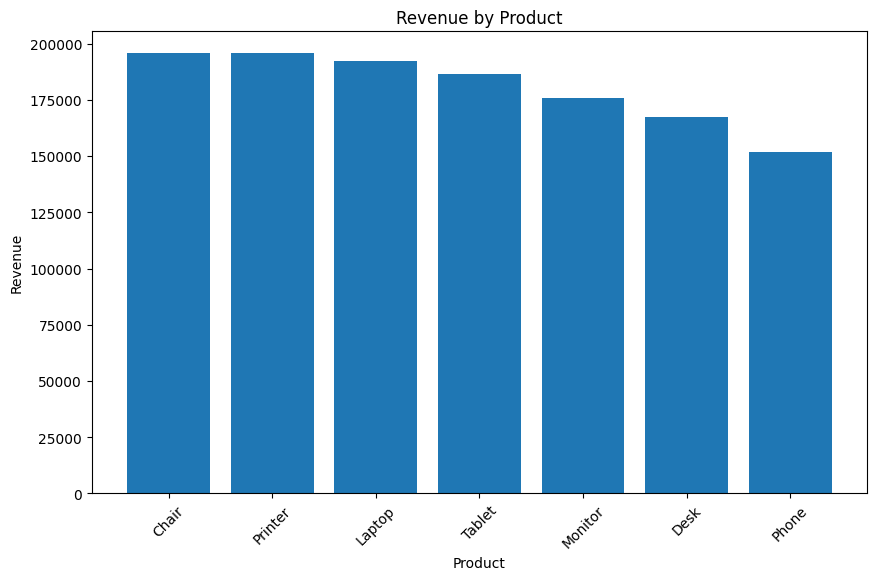

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(product_revenue["Product"], product_revenue["Revenue"])
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

The chart shows which products generate the highest revenue. Products with taller bars contribute more to the overall business revenue.

In [56]:
query = """
SELECT PaymentMethod,
COUNT(*) AS Orders
FROM orders
GROUP BY PaymentMethod;
"""

payment = pd.read_sql(query, conn)

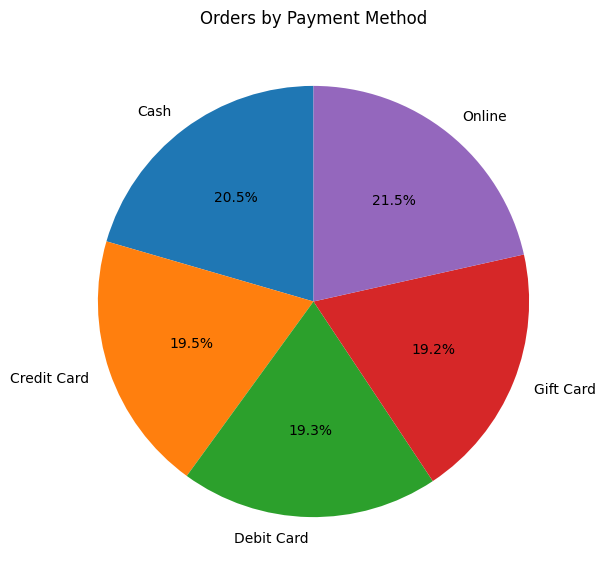

In [57]:
plt.figure(figsize=(7,7))
plt.pie(payment["Orders"],
        labels=payment["PaymentMethod"],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Orders by Payment Method")
plt.show()

This chart shows the percentage of orders completed using each payment method.

In [61]:
query = """
SELECT OrderStatus,
SUM(TotalPrice) AS Revenue
FROM orders
GROUP BY OrderStatus;
"""

status = pd.read_sql(query, conn)

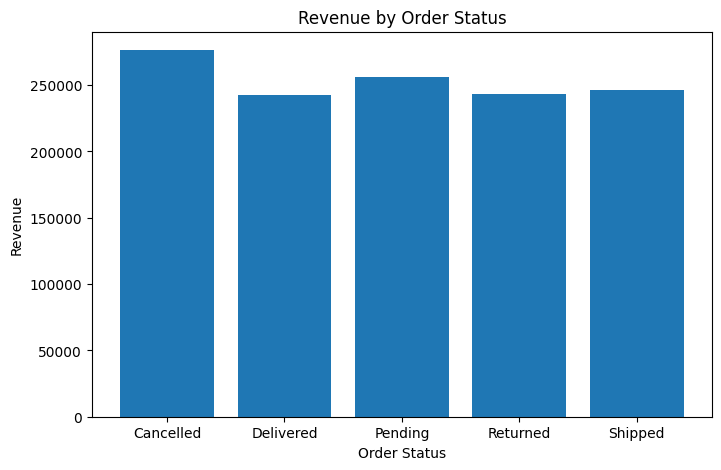

In [62]:
plt.figure(figsize=(8,5))
plt.bar(status["OrderStatus"], status["Revenue"])
plt.title("Revenue by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Revenue")
plt.show()

This visualization compares the revenue generated by each order status.

In [64]:
query = """
SELECT ReferralSource,
COUNT(*) AS Orders
FROM orders
GROUP BY ReferralSource;
"""

referral = pd.read_sql(query, conn)

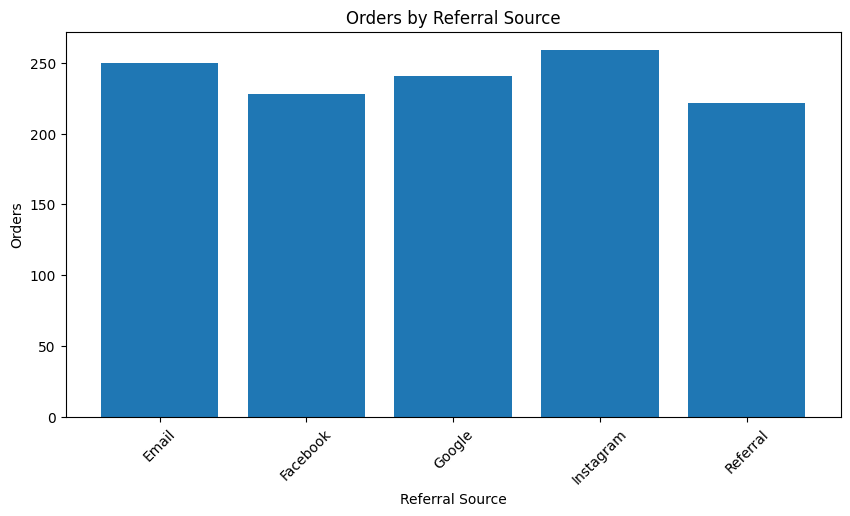

In [65]:
plt.figure(figsize=(10,5))
plt.bar(referral["ReferralSource"], referral["Orders"])
plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

This chart identifies which referral sources bring the highest number of customer orders.

# Conclusion

This project demonstrated the practical use of SQL for extracting meaningful insights from business data.

The following SQL concepts were successfully implemented:

- SELECT
- WHERE
- ORDER BY
- GROUP BY
- COUNT()
- SUM()
- AVG()
- HAVING

Using SQL within Jupyter Notebook and SQLite, business questions such as total revenue, order distribution, product performance, and payment method analysis were answered efficiently. This project strengthened my understanding of SQL querying and data analysis techniques used in real-world business environments.

In [66]:
conn.close()

print("Database connection closed successfully.")

Database connection closed successfully.
